In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [29]:
df.shape

(10000, 14)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [31]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [32]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [33]:
df['Exited'].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

### Target Distribution

The target variable `Exited` shows a clear class imbalance:
- 79.63% of customers did not leave the bank.
- 20.37% of customers exited.

This imbalance should be considered during model training and evaluation, since accuracy alone may not fully reflect the model's ability to identify customers who are likely to churn.

In [37]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [40]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [41]:
df.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

In [42]:
print("HasCrCard:")
print(df['HasCrCard'].value_counts())

print("\nIsActiveMember:")
print(df['IsActiveMember'].value_counts())

print("\nNumOfProducts:")
print(df['NumOfProducts'].value_counts())

HasCrCard:
HasCrCard
1    7055
0    2945
Name: count, dtype: int64

IsActiveMember:
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

NumOfProducts:
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


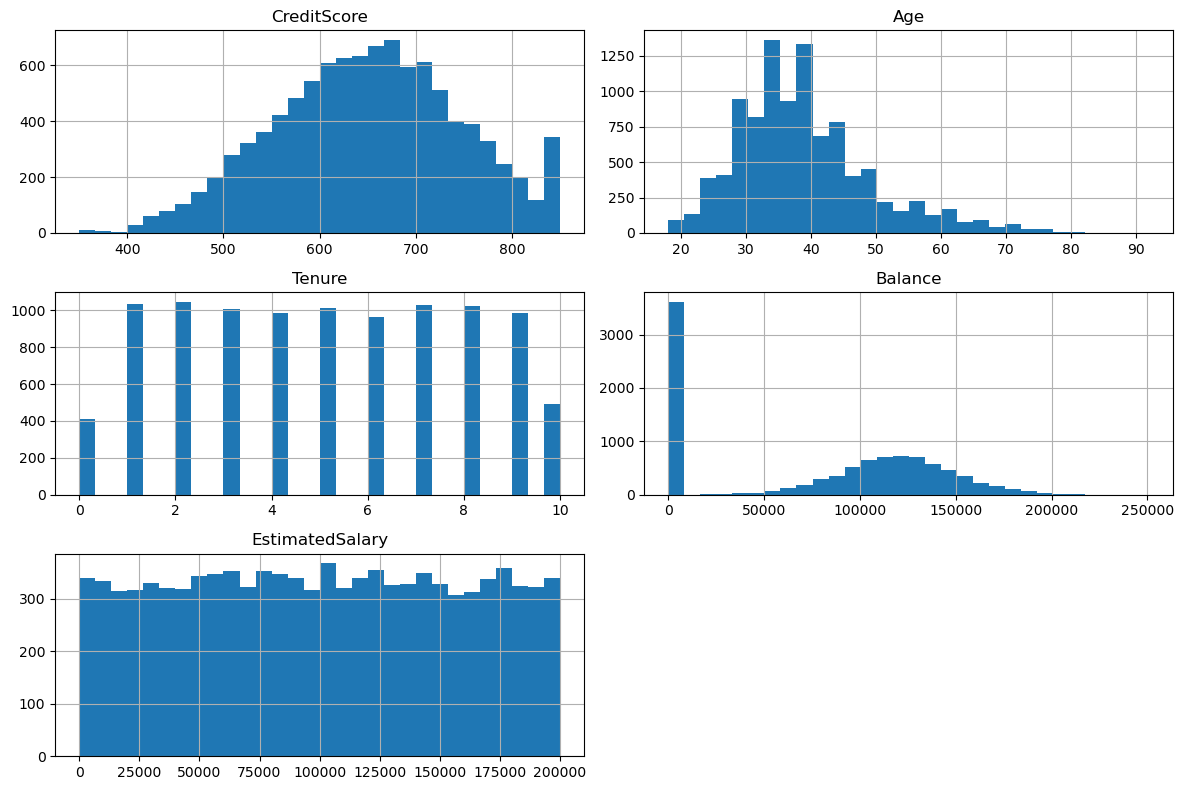

In [43]:
df[['CreditScore', 'Age', 'Tenure', 'Balance', 
    'EstimatedSalary']].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

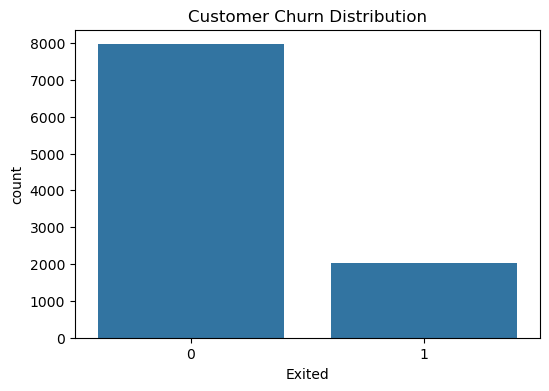

In [44]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Exited')
plt.title('Customer Churn Distribution')
plt.show()

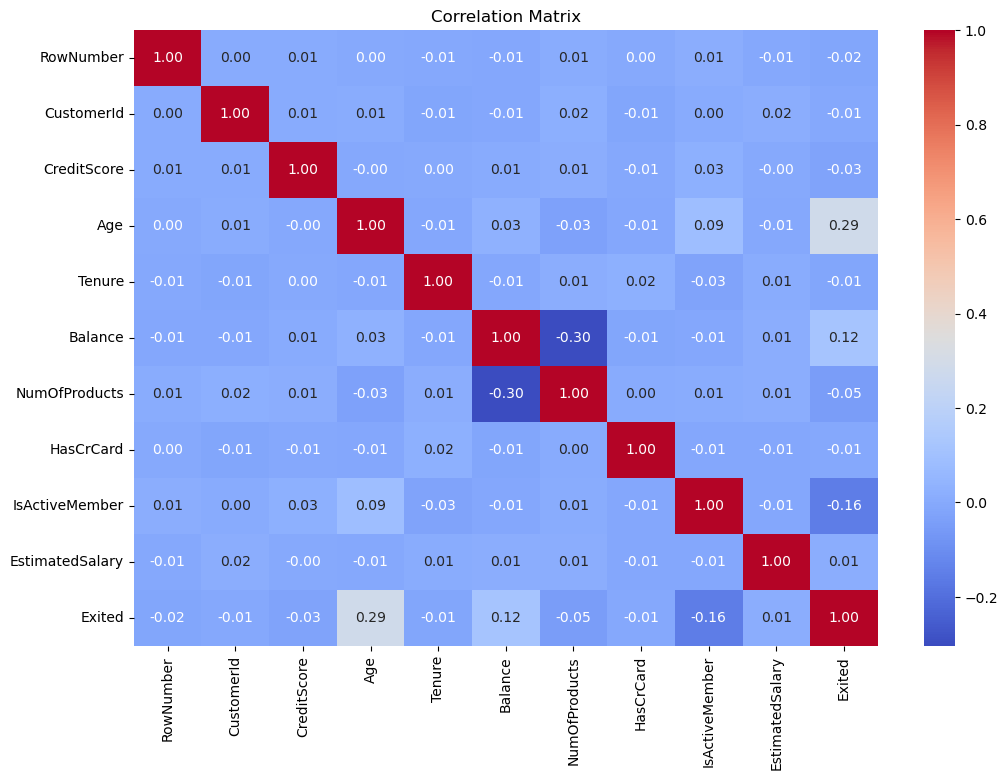

In [45]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [46]:
pd.crosstab(df['Geography'], df['Exited'], normalize='index') * 100

Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


In [47]:
pd.crosstab(df['Gender'], df['Exited'], normalize='index') * 100

Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


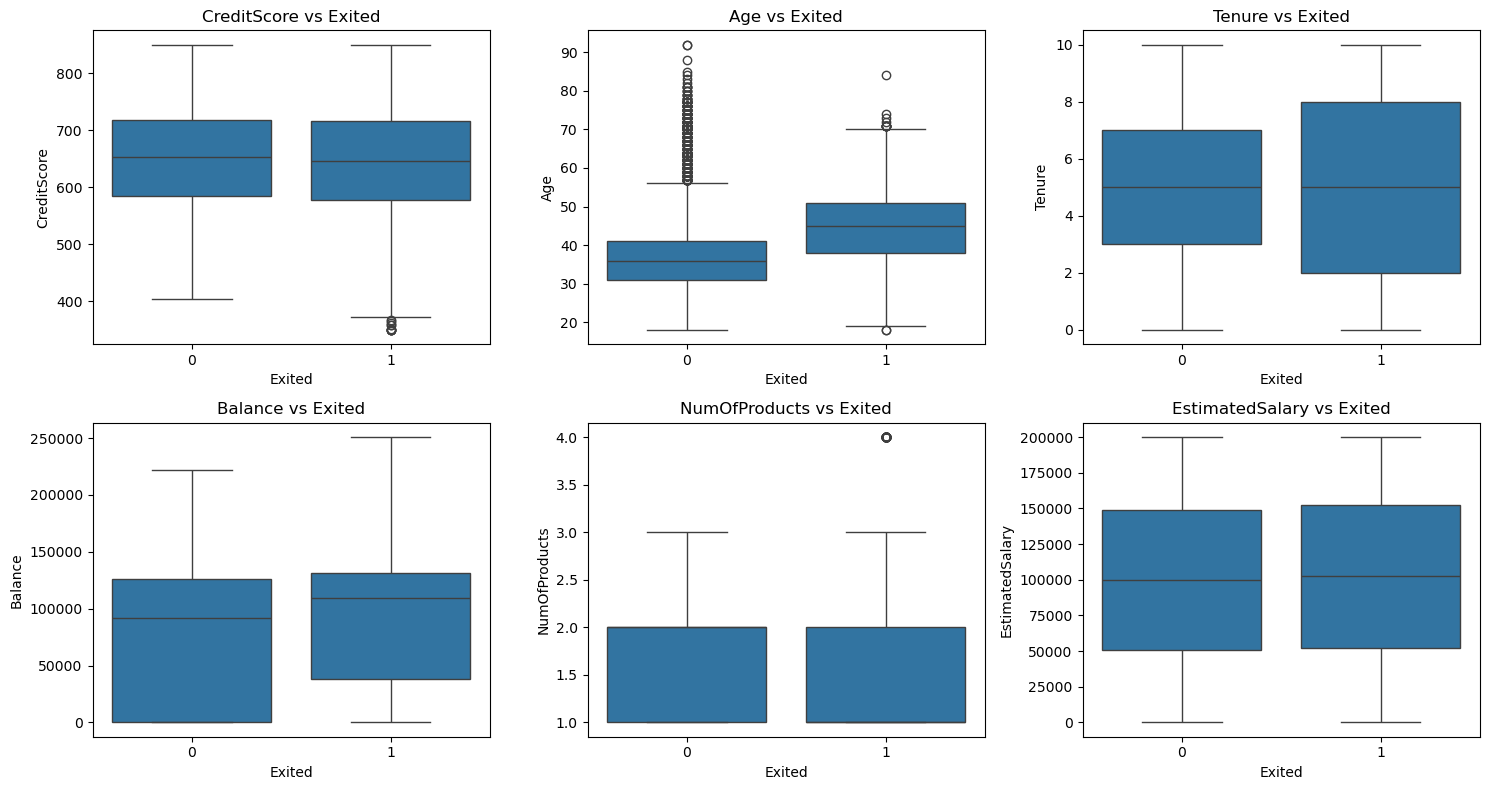

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

for ax, feature in zip(axes.flat, features):
    sns.boxplot(data=df, x='Exited', y=feature, ax=ax)
    ax.set_title(f'{feature} vs Exited')

plt.tight_layout()
plt.show()

In [49]:
# Remove columns that are not useful for the model
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

In [50]:
# Convert categorical features into numerical values
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [51]:
# Convert boolean values to integers
df = df.astype(int)

In [53]:
# Check the dataset after preprocessing
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,1,0,0,0
1,608,41,1,83807,1,0,1,112542,0,0,1,0
2,502,42,8,159660,3,1,0,113931,1,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0,0
4,850,43,2,125510,1,1,1,79084,0,0,1,0


In [54]:
X = df.drop(columns=['Exited'])
y = df['Exited']

In [55]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 11)
y shape: (10000,)


In [61]:
from sklearn.preprocessing import MinMaxScaler

# بنعمل Scaling للـfeatures عشان نخلي القيم في نفس الـrange
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [62]:
# بنرجع الـscaled data لـDataFrame ونحافظ على أسماء الـfeatures
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,0.538,0.324324,0.2,0.000000,0.000000,1.0,1.0,0.506733,0.0,0.0,0.0
1,0.516,0.310811,0.1,0.334028,0.000000,0.0,1.0,0.562708,0.0,1.0,0.0
2,0.304,0.324324,0.8,0.636354,0.666667,1.0,0.0,0.569654,0.0,0.0,0.0
3,0.698,0.283784,0.1,0.000000,0.333333,0.0,0.0,0.469120,0.0,0.0,0.0
4,1.000,0.337838,0.2,0.500243,0.000000,1.0,1.0,0.395403,0.0,1.0,0.0


In [63]:
from sklearn.model_selection import train_test_split

# بنقسم الـdata إلى Training وTesting عشان نقدر نقيس أداء الـmodel
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=1
)

In [64]:
# بنتأكد إن الـdata اتقسمت بالشكل الصحيح
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 11)
X_test: (2000, 11)
y_train: (8000,)
y_test: (2000,)


In [73]:
from tensorflow import keras
from tensorflow.keras import layers

# Build the model
model = keras.Sequential()

# Input layer
model.add(keras.Input(shape=(11,)))

# Hidden layers
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(8, activation='relu'))

# Output layer
model.add(layers.Dense(1, activation='sigmoid'))

In [74]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [75]:
# Display the model structure
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7961 - loss: 0.5047 - val_accuracy: 0.7975 - val_loss: 0.4745
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7983 - loss: 0.4579 - val_accuracy: 0.8056 - val_loss: 0.4569
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8078 - loss: 0.4426 - val_accuracy: 0.8100 - val_loss: 0.4439
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8109 - loss: 0.4326 - val_accuracy: 0.8131 - val_loss: 0.4364
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8173 - loss: 0.4255 - val_accuracy: 0.8106 - val_loss: 0.4299
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8205 - loss: 0.4174 - val_accuracy: 0.8125 - val_loss: 0.4209
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8272 - loss: 0.4061 - val_accuracy: 0.8238 - val_loss: 0.4125
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8347 - loss: 0.3945 - val_accuracy: 0.

In [77]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8675 - loss: 0.3366   
Test Loss: 0.3366330564022064
Test Accuracy: 0.8675000071525574


In [81]:
# نحاول تحسين الـNeural Network والـHyperparameters ونشوف هل نقدر نوصل لـ90% تقريبًا. 

In [82]:
# Build the second model
model_2 = keras.Sequential()

# Hidden layers
model_2.add(keras.Input(shape=(11,)))
model_2.add(layers.Dense(64, activation='relu'))
model_2.add(layers.Dense(32, activation='relu'))
model_2.add(layers.Dense(16, activation='relu'))

# Output layer
model_2.add(layers.Dense(1, activation='sigmoid'))

In [83]:
# Compile the model
model_2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [84]:
# Train the model
history_2 = model_2.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7972 - loss: 0.4846 - val_accuracy: 0.7975 - val_loss: 0.4614
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8034 - loss: 0.4482 - val_accuracy: 0.8112 - val_loss: 0.4437
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8139 - loss: 0.4306 - val_accuracy: 0.8188 - val_loss: 0.4270
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8209 - loss: 0.4114 - val_accuracy: 0.8256 - val_loss: 0.4004
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8369 - loss: 0.3893 - val_accuracy: 0.8481 - val_loss: 0.3803
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8458 - loss: 0.3710 - val_accuracy: 0.8512 - val_loss: 0.3671
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8512 - loss: 0.3609 - val_accuracy: 0.8494 - val_loss: 0.3627
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8539 - loss: 0.3538 - val_accu

In [85]:
# Check the best validation accuracy
best_val_accuracy = max(history_2.history['val_accuracy'])

print("Best Validation Accuracy:", best_val_accuracy)

Best Validation Accuracy: 0.8550000190734863


### Model Performance

The second model did not improve the validation accuracy, so increasing the number of neurons and epochs did not improve the model performance.

In [87]:
# Build the third model
model_3 = keras.Sequential()

# Hidden layers
model_3.add(keras.Input(shape=(11,)))
model_3.add(layers.Dense(32, activation='relu'))
model_3.add(layers.Dense(16, activation='relu'))
model_3.add(layers.Dense(8, activation='relu'))

# Output layer
model_3.add(layers.Dense(1, activation='sigmoid'))

In [88]:
# Compile the model
model_3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [89]:
# Train the model
history_3 = model_3.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7437 - loss: 0.5423 - val_accuracy: 0.7975 - val_loss: 0.4844
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7972 - loss: 0.4711 - val_accuracy: 0.7975 - val_loss: 0.4705
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7975 - loss: 0.4590 - val_accuracy: 0.7975 - val_loss: 0.4625
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7994 - loss: 0.4494 - val_accuracy: 0.8000 - val_loss: 0.4561
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8073 - loss: 0.4394 - val_accuracy: 0.8163 - val_loss: 0.4400
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8189 - loss: 0.4263 - val_accuracy: 0.8231 - val_loss: 0.4257
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8284 - loss: 0.4125 - val_accuracy: 0.8256 - val_loss: 0.4147
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8344 - loss: 0.3972 - val_accu

In [90]:
# Check the best validation accuracy
best_val_accuracy_3 = max(history_3.history['val_accuracy'])

print("Best Validation Accuracy:", best_val_accuracy_3)

Best Validation Accuracy: 0.856249988079071


### خلاصة الـModeling

جرّبنا 3 إعدادات مختلفة للـModel، مع تغيير الـArchitecture وبعض إعدادات التدريب. أفضل نتيجة كانت من التجربة الأولى، حيث حققت Accuracy حوالي 86%، لذلك سنعتمد عليها في الخطوات التالية.

In [91]:
# عمل predictions على الـtest data
y_pred_prob = model.predict(X_test)

# تحويل الـprobabilities إلى classes
y_pred = (y_pred_prob >= 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [96]:
from sklearn.metrics import accuracy_score

# حساب الـAccuracy على الـtest data
test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8675


In [97]:
# عمل predictions على الـtest data
y_pred_prob = model.predict(X_test)

# تحويل الـprobabilities إلى classes
y_pred_class = (y_pred_prob >= 0.5).astype(int).ravel()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


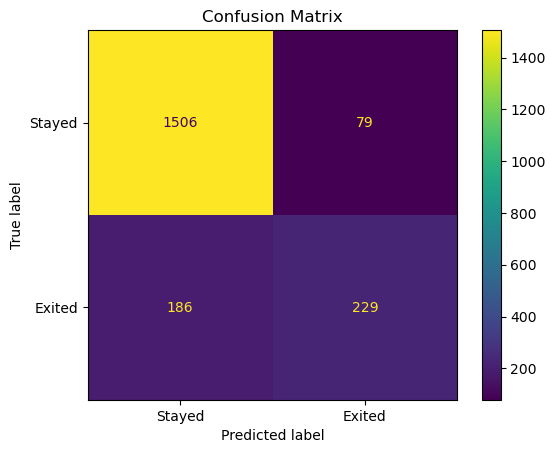

In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# عرض Confusion Matrix لمعرفة أداء الـmodel على كل class
cm = confusion_matrix(y_test, y_pred_class)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stayed', 'Exited']
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()